## Reglas de asociación - Análisis

Se interpretan las reglas generadas en `c_reglas.ipynb`

### Imports

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
import matplotlib.patches as mpatches

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})

### Utilidades

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
reglas_dir = proyecto / "05_Asociacion" / "temp" / "c_reglas"

spark = SparkSession.builder.appName("asociacion-analisis").master("local[*]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

pd.set_option("display.max_colwidth", 80)

### 1. Carga de reglas

In [3]:
assert (reglas_dir / "fpg_full").exists(), "Corre c_reglas.ipynb (Run All) antes que este notebook."

reglas_fpg_full = spark.read.parquet(str(reglas_dir / "fpg_full")).toPandas()
reglas_apriori_q4 = spark.read.parquet(str(reglas_dir / "apriori_q4")).toPandas()

print(f"Reglas disponibles (completo): {len(reglas_fpg_full):,} | (Apriori, Q4): {len(reglas_apriori_q4):,}")

Reglas disponibles (completo): 497 | (Apriori, Q4): 579


### 2. Reglas relevantes

- Se separan las 497 reglas en dos grupos: `reglas_p1` (37, con `comp=postor_unico`) y `reglas_otras` (460, el resto)

- Cada grupo se ordena por `lift` descendente

- Se toman las top 7 de `reglas_p1` + las top 7 de `reglas_otras` = 14 reglas

- Se marca cuáles también aparecen en el subconjunto Apriori-Q4 (`estable_en_q4`)

In [4]:
def involucra_postor_unico(items):
    return "comp=postor_unico" in items

es_p1 = reglas_fpg_full["antecedente"].apply(involucra_postor_unico) | reglas_fpg_full["consecuente"].apply(involucra_postor_unico)

reglas_p1 = reglas_fpg_full[es_p1].sort_values("lift", ascending=False)
reglas_otras = reglas_fpg_full[~es_p1].sort_values("lift", ascending=False)

print(f"Reglas relacionadas con postor_unico: {len(reglas_p1):,} | otras: {len(reglas_otras):,}")
reglas_p1.head(10)

Reglas relacionadas con postor_unico: 37 | otras: 460


,antecedente,consecuente,soporte,confianza,lift,interes,redundante
241,"[comp=postor_unico, monto=2_50k-200k]",[met=CONTRATACIÓN DIRECTA],0.023191,0.585966,10.012178,0.527440,False
114,"[reg=LIMA, rubro=80]","[cat=SERVICES, comp=postor_unico]",0.026479,0.676503,9.932917,0.608396,False
38,"[monto=1_<50k, reg=LIMA]","[cat=SERVICES, comp=postor_unico]",0.020734,0.663299,9.739047,0.595192,False
242,"[met=CONTRATACIÓN DIRECTA, monto=2_50k-200k]",[comp=postor_unico],0.023191,0.935276,9.344874,0.835191,False
243,"[met=CONTRATACIÓN DIRECTA, reg=LIMA]",[comp=postor_unico],0.025744,0.887944,8.871955,0.787860,False
36,"[cat=SERVICES, monto=1_<50k]","[comp=postor_unico, reg=LIMA]",0.020734,0.565612,8.861390,0.501784,False
239,"[cat=SERVICES, met=CONTRATACIÓN DIRECTA]",[comp=postor_unico],0.031782,0.884009,8.832641,0.783925,False
237,[met=CONTRATACIÓN DIRECTA],[comp=postor_unico],0.050622,0.864957,8.642277,0.764872,False
236,[comp=postor_unico],[met=CONTRATACIÓN DIRECTA],0.050622,0.505792,8.642277,0.447267,False
115,"[cat=SERVICES, comp=postor_unico, reg=LIMA]",[rubro=80],0.026479,0.532678,8.561845,0.470462,False


In [5]:
set_q4 = set(zip(reglas_apriori_q4["antecedente"].apply(tuple), reglas_apriori_q4["consecuente"].apply(tuple)))

seleccion = pd.concat([reglas_p1.head(7), reglas_otras.head(7)]).reset_index(drop=True)
seleccion["estable_en_q4"] = seleccion.apply(
    lambda r: (tuple(r["antecedente"]), tuple(r["consecuente"])) in set_q4, axis=1)

print(f"Reglas seleccionadas: {len(seleccion)} ({int(seleccion['redundante'].sum())} redundantes)")
seleccion[["antecedente", "consecuente", "soporte", "confianza", "lift", "interes", "redundante", "estable_en_q4"]]

Reglas seleccionadas: 14 (1 redundantes)


,antecedente,consecuente,soporte,confianza,lift,interes,redundante,estable_en_q4
0,"[comp=postor_unico, monto=2_50k-200k]",[met=CONTRATACIÓN DIRECTA],0.023191,0.585966,10.012178,0.527440,False,False
1,"[reg=LIMA, rubro=80]","[cat=SERVICES, comp=postor_unico]",0.026479,0.676503,9.932917,0.608396,False,False
2,"[monto=1_<50k, reg=LIMA]","[cat=SERVICES, comp=postor_unico]",0.020734,0.663299,9.739047,0.595192,False,False
3,"[met=CONTRATACIÓN DIRECTA, monto=2_50k-200k]",[comp=postor_unico],0.023191,0.935276,9.344874,0.835191,False,False
4,"[met=CONTRATACIÓN DIRECTA, reg=LIMA]",[comp=postor_unico],0.025744,0.887944,8.871955,0.787860,False,True
5,"[cat=SERVICES, monto=1_<50k]","[comp=postor_unico, reg=LIMA]",0.020734,0.565612,8.861390,0.501784,False,False
6,"[cat=SERVICES, met=CONTRATACIÓN DIRECTA]",[comp=postor_unico],0.031782,0.884009,8.832641,0.783925,False,True
7,"[met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]","[cat=WORKS, comp=varios_postores]",0.024333,0.935318,9.699986,0.838893,False,True
8,"[comp=varios_postores, met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]",[cat=WORKS],0.024333,1.000000,8.524412,0.882690,True,True
9,"[met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]",[cat=WORKS],0.026016,1.000000,8.524412,0.882690,False,True


#### a. Lift - Postor único

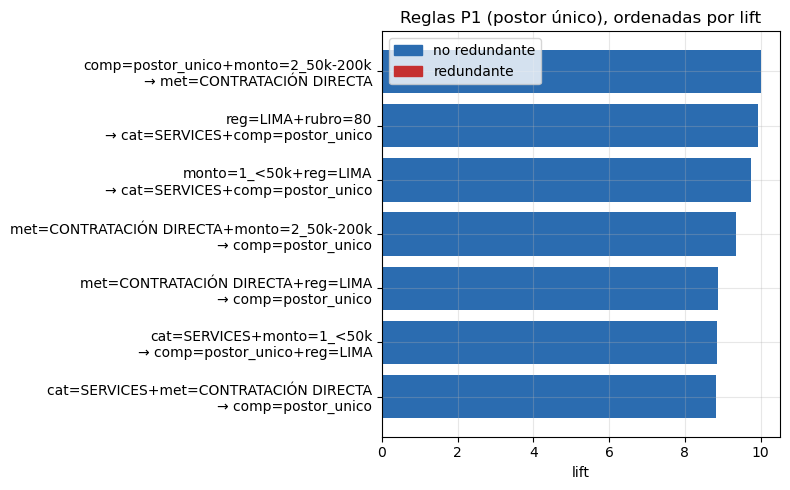

In [6]:
grupo_p1 = seleccion.iloc[:7]
etiqueta_p1 = (grupo_p1["antecedente"].apply(lambda a: "+".join(a))
               + "\n→ " + grupo_p1["consecuente"].apply(lambda c: "+".join(c)))

orden_p1 = grupo_p1["lift"].sort_values().index
y_pos = range(len(orden_p1))
colores_p1 = grupo_p1.loc[orden_p1, "redundante"].map({True: "#c53030", False: "#2b6cb0"})

plt.figure(figsize=(8, 5))
plt.barh(y_pos, grupo_p1.loc[orden_p1, "lift"], color=colores_p1)
plt.yticks(list(y_pos), etiqueta_p1[orden_p1])
plt.xlabel("lift"); plt.title("Reglas P1 (postor único), ordenadas por lift")
plt.legend(handles=[mpatches.Patch(color="#2b6cb0", label="no redundante"),
                     mpatches.Patch(color="#c53030", label="redundante")],
           loc="upper left")
plt.tight_layout(); plt.show()

#### b. Lift - Demás

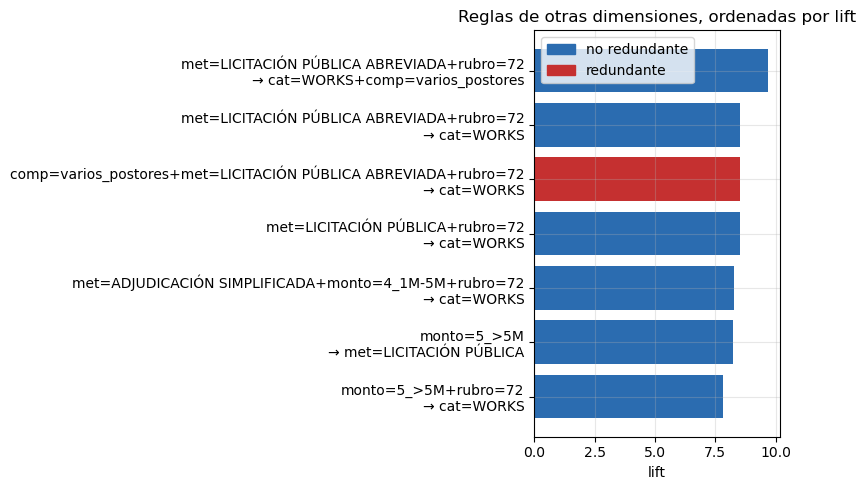

In [7]:
grupo_otras = seleccion.iloc[7:]
etiqueta_otras = (grupo_otras["antecedente"].apply(lambda a: "+".join(a))
                   + "\n→ " + grupo_otras["consecuente"].apply(lambda c: "+".join(c)))

orden_otras = grupo_otras["lift"].sort_values().index
y_pos = range(len(orden_otras))
colores_otras = grupo_otras.loc[orden_otras, "redundante"].map({True: "#c53030", False: "#2b6cb0"})

plt.figure(figsize=(8, 5))
plt.barh(y_pos, grupo_otras.loc[orden_otras, "lift"], color=colores_otras)
plt.yticks(list(y_pos), etiqueta_otras[orden_otras])
plt.xlabel("lift"); plt.title("Reglas de otras dimensiones, ordenadas por lift")
plt.legend(handles=[mpatches.Patch(color="#2b6cb0", label="no redundante"),
                     mpatches.Patch(color="#c53030", label="redundante")],
           loc="upper left")
plt.tight_layout(); plt.show()

- De 497 reglas totales, solo 37 (7.4%) involucran `comp=postor_unico`

- Se tienen 14 seleccionadas (7 de P1 + 7 de otras dimensiones)

- 8 de las 14 aparecen en el subconjunto Apriori-Q4 (`estable_en_q4=True`)

- Todas las de `rubro=72`→`cat=WORKS` y la de `monto=5_>5M`→`met=LICITACIÓN PÚBLICA` son estables

- De 7 de P1, 2 se repiten en Q4 (las que combinan `met=CONTRATACIÓN DIRECTA` con región o categoría)

- Solo 1 de las 14 es redundante: la versión de la regla de `rubro=72` con `comp=varios_postores` 

### 3. Interpretación

Se interpretan las top reglas obtenidas

#### a. Postor único

La regla — `{met=CONTRATACIÓN DIRECTA} → {comp=postor_unico}`, confianza 86.5% no entra en el top, pero se usa para validar

**1. `{comp=postor_unico, monto=2_50k-200k} → {met=CONTRATACIÓN DIRECTA}`** 

- Confianza 58.6%, lift 10.0
- Dirección inversa: dado que un proceso ya es de postor único y de monto medio, más de la mitad
  termina siendo Contratación Directa
- Lift tan alto porque Contratación Directa es poco frecuente en general (5.9% de soporte)

**2. `{reg=LIMA, rubro=80} → {cat=SERVICES, comp=postor_unico}`** 

- Confianza 67.6%, lift 9.9, no estable en Q4
- `rubro=80` ("servicios de gestión/profesionales") en Lima casi siempre es `cat=SERVICES`
- 67.6% de esos procesos tienen un solo postor — geografía+rubro con alta concentración de baja competencia

**3. `{monto=1_<50k, reg=LIMA} → {cat=SERVICES, comp=postor_unico}`**

- Confianza 66.3%, lift 9.7, no estable en Q4
- Extiende el hallazgo de tramo bajo (57.3% de postor único en `1_<50k`) agregando región
- En Lima específicamente, los montos chicos en servicios concentran más baja competencia que el promedio nacional del tramo

**4. `{met=CONTRATACIÓN DIRECTA, monto=2_50k-200k} → {comp=postor_unico}`**

- Confianza 93.5%, lift 9.3, interés 0.835, no estable en Q4
- Combinar método + tramo de monto sube la confianza muy por encima del método
- Se logra concentran más al cruzar dimensiones, exactamente lo que Apriori/FP-Growth debe

**5. `{met=CONTRATACIÓN DIRECTA, reg=LIMA} → {comp=postor_unico}`**

- Confianza 88.8%, lift 8.9, estable en Q4
- Contratación Directa en Lima específicamente es aún más propensa a postor único que Contratación Directa 
- Refuerza el hallazgo de Lima como región de riesgo

**6. `{cat=SERVICES, monto=1_<50k} → {comp=postor_unico, reg=LIMA}`**

- Confianza 56.6%, lift 8.9, no estable en Q4
- Servicios de monto bajo predicen a la vez postor único y Lima como región

**7. `{cat=SERVICES, met=CONTRATACIÓN DIRECTA} → {comp=postor_unico}`**

- Confianza 88.4%, lift 8.8, estable en Q4
- Contratación Directa en servicios también sube por encima del método solo

#### b. Demás

Se usa como informacion adicional y util para el análisis, y para contrastar las anteriores

**8. `{met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72} → {cat=WORKS, comp=varios_postores}`** 

- Confianza 93.5%, lift 9.7, estable en Q4
- Un método competitivo + rubro de obras predice **varios postores**, no uno solo 
- Métodos competitivos funcionan como deberían cuando se trata de obras


**9. `{comp=varios_postores, met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72} → {cat=WORKS}`**

- Confianza 100%, lift 8.52, marcada `redundante=True`
- Agregar `comp=varios_postores` al antecedente no mejora una confianza que ya era perfecta en la versión más simple (regla 10)

**10. `{met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72} → {cat=WORKS}`** 

- Confianza 100%, estable en Q4
- `rubro=72` mapea de forma casi determinista a `cat=WORKS` en el estándar UNSPSC

**11. `{met=LICITACIÓN PÚBLICA, rubro=72} → {cat=WORKS}`** 

- Confianza 99.98%, lift 8.52, estable en Q4
- Ahora con la variante "no abreviada" del método — refuerza `rubro=72`→`cat=WORKS`

**12. `{met=ADJUDICACIÓN SIMPLIFICADA, monto=4_1M-5M, rubro=72} → {cat=WORKS}`**

- Confianza 97.0%, lift 8.27, no estable en Q4
- confirma que la regla `rubro=72→WORKS` es robusta a través de métodos y montos

**13. `{monto=5_>5M} → {met=LICITACIÓN PÚBLICA}`** 

- Confianza 51.7%, lift 8.23, estable en Q4
- Los procesos de monto muy alto (>5M) tienden a usar Licitación Pública 
- Método que la ley de contrataciones exige para los montos mayores

**14. `{monto=5_>5M, rubro=72} → {cat=WORKS}`** 

- Confianza 91.5%, lift 7.80, estable en Q4
- Refuerza las reglas 10-11 (`rubro=72`→`cat=WORKS`)
- Muestra además que los montos más grandes del dataset se concentran en obras

---
### 4. Síntesis

In [8]:
seleccion[["antecedente", "consecuente", "soporte", "confianza", "lift", "interes", "redundante"]]

,antecedente,consecuente,soporte,confianza,lift,interes,redundante
0,"[comp=postor_unico, monto=2_50k-200k]",[met=CONTRATACIÓN DIRECTA],0.023191,0.585966,10.012178,0.527440,False
1,"[reg=LIMA, rubro=80]","[cat=SERVICES, comp=postor_unico]",0.026479,0.676503,9.932917,0.608396,False
2,"[monto=1_<50k, reg=LIMA]","[cat=SERVICES, comp=postor_unico]",0.020734,0.663299,9.739047,0.595192,False
3,"[met=CONTRATACIÓN DIRECTA, monto=2_50k-200k]",[comp=postor_unico],0.023191,0.935276,9.344874,0.835191,False
4,"[met=CONTRATACIÓN DIRECTA, reg=LIMA]",[comp=postor_unico],0.025744,0.887944,8.871955,0.787860,False
5,"[cat=SERVICES, monto=1_<50k]","[comp=postor_unico, reg=LIMA]",0.020734,0.565612,8.861390,0.501784,False
6,"[cat=SERVICES, met=CONTRATACIÓN DIRECTA]",[comp=postor_unico],0.031782,0.884009,8.832641,0.783925,False
7,"[met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]","[cat=WORKS, comp=varios_postores]",0.024333,0.935318,9.699986,0.838893,False
8,"[comp=varios_postores, met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]",[cat=WORKS],0.024333,1.000000,8.524412,0.882690,True
9,"[met=LICITACIÓN PÚBLICA ABREVIADA, rubro=72]",[cat=WORKS],0.026016,1.000000,8.524412,0.882690,False


- Se confirma y **refinan** lo que el EDA ya mostraba un factor a la vez: `metodo_detalle`, `tramo_monto` y `region` por separado ya marcaban patrón de baja competencia

- Combinados en pares (método+monto, método+región, método+categoría) la confianza sube consistentemente por encima del método solo (hasta 93.5% vs 86.5%, regla 4)

- La selección se dividió a propósito en dos mitades iguales: 7 reglas de P1 (competencia) y 7 de otras dimensiones, para no sesgar la vision hacia un solo tema

- La regla 8 (método competitivo + obras → varios postores) es un buen contraste: confirma que, cuando el método realmente exige competencia, el patrón se invierte

- Las reglas 9-12 y 14 (`rubro=72`→`cat=WORKS` bajo distintos métodos y montos) no aportan a P1 pero sí confirman la consistencia de la codificación UNSPSC

- La regla 13 (monto muy alto → Licitación Pública) refleja una exigencia normativa, no un patrón de riesgo

---
### 5. Cerrar sesión

In [9]:
spark.stop()